<a href="https://colab.research.google.com/github/AlbertPuentes/Deep-Learning-week2./blob/main/NeuronaBasicaWeek2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Resultados de la Evaluación Automática de Creditos:



,Cliente,Historial (x1),Ingresos (x2),Puntaje Interno (z),Decisión del Banco
0,Cliente A,Malo,Bajos,-0.5,Denegado (0)
1,Cliente B,Malo,Altos,0.5,Aprobado (1)
2,Cliente C,Bueno,Bajos,0.5,Aprobado (1)
3,Cliente D,Bueno,Altos,1.5,Aprobado (1)


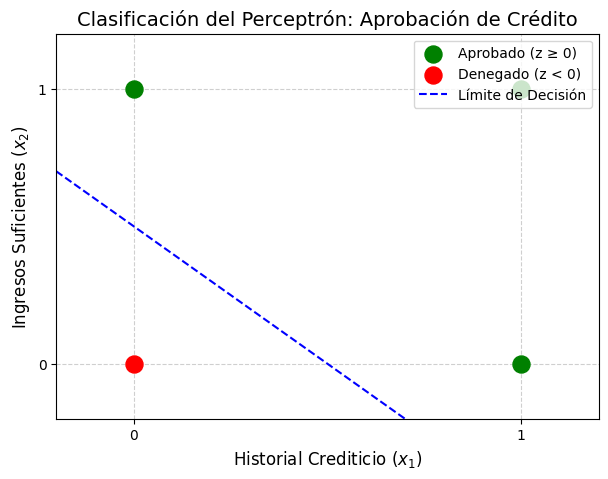

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pesos_credito = [1.0, 1.0]
bias_credito = -0.5
modelo_credito = NeuronaBasica(pesos=pesos_credito, bias=bias_credito)

perfiles_clientes = [
    [0, 0], # Cliente A: Sin historial, ingresos bajos
    [0, 1], # Cliente B: Sin historial, ingresos altos
    [1, 0], # Cliente C: Buen historial, ingresos bajos
    [1, 1]  # Cliente D: Buen historial, ingresos altos
]

resultados_credito = []
nombres = ['Cliente A', 'Cliente B', 'Cliente C', 'Cliente D']
for i, x in enumerate(perfiles_clientes):
    z_score, aprobacion = modelo_credito.predecir(x)

    resultados_credito.append({
        "Cliente": nombres[i],
        "Historial (x1)": "Bueno" if x[0] == 1 else "Malo",
        "Ingresos (x2)": "Altos" if x[1] == 1 else "Bajos",
        "Puntaje Interno (z)": round(z_score, 2),
        "Decisión del Banco": "Aprobado (1)" if aprobacion == 1 else "Denegado (0)"
    })

print("Resultados de la Evaluación Automática de Creditos:\n")
df_credito = pd.DataFrame(resultados_credito)
display(df_credito)

plt.figure(figsize=(7, 5))

x1_aprobados = [x[0] for i, x in enumerate(perfiles_clientes) if resultados_credito[i]["Decisión del Banco"] == "Aprobado (1)"]
x2_aprobados = [x[1] for i, x in enumerate(perfiles_clientes) if resultados_credito[i]["Decisión del Banco"] == "Aprobado (1)"]

x1_denegados = [x[0] for i, x in enumerate(perfiles_clientes) if resultados_credito[i]["Decisión del Banco"] == "Denegado (0)"]
x2_denegados = [x[1] for i, x in enumerate(perfiles_clientes) if resultados_credito[i]["Decisión del Banco"] == "Denegado (0)"]

plt.scatter(x1_aprobados, x2_aprobados, color='green', label='Aprobado (z ≥ 0)', s=150, zorder=5)
plt.scatter(x1_denegados, x2_denegados, color='red', label='Denegado (z < 0)', s=150, zorder=5)

x_linea = np.linspace(-0.2, 1.2, 10)
y_linea = -(pesos_credito[0] / pesos_credito[1]) * x_linea - (bias_credito / pesos_credito[1])

plt.plot(x_linea, y_linea, '--', color='blue', label='Límite de Decisión')

plt.title('Clasificación del Perceptrón: Aprobación de Crédito', fontsize=14)
plt.xlabel('Historial Crediticio ($x_1$)', fontsize=12)
plt.ylabel('Ingresos Suficientes ($x_2$)', fontsize=12)
plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')

#gráfica
plt.show()